# MEV — Reordering Slippage: Polygon vs. Ethereum Mainnet
**Pesquisa FAPEMIG** | Coordenador: Prof. José Augusto Miranda Nacif | Bolsista: Aline Cristina Santos Silva

---

## Objetivo
Comparar o *Reordering Slippage* no pool **USDC/WETH 0.05%** da Uniswap V3 na rede **Polygon**
com a linha de base da **Ethereum Mainnet** reportada por Adams et al. (2023),
usando a **mesma janela de tempo** do artigo (janeiro–agosto 2023) e dados atuais (2026).

### Artigo de referência
> Adams, A., Chan, B.Y., Markovich, S., Wan, X. (2023).  
> *Don't Let MEV Slip: The Costs of Swapping on the Uniswap Protocol.*  
> arXiv:2309.13648. Financial Cryptography 2024.

**Período do artigo:** 21 jan 2023 → 14 ago 2023 (≈7 meses, 284.031 swaps na Mainnet)

**Nossa estratégia:** Coletar dados em janelas mensais/quinzenais dentro do mesmo período,
maximizando o número de swaps dentro do limite do plano gratuito da Alchemy.

---

## Estrutura do notebook
| Seção | Descrição |
|---|---|
| 1 | Instalação e configuração |
| 2 | Documentação do contrato (PolygonScan) |
| 3 | Mapeamento de datas → blocos Polygon |
| 4 | Coleta 2023 (período do artigo) |
| 5 | Coleta 2026 (dados atuais) |
| 6 | Processamento e cálculo do Reordering Slippage |
| 7 | Análise e comparação com a Mainnet |

## 1. Instalação e Configuração

Aqui são feitas 3 coisas:
- Instalção das bibliotecas: *web3* para manter a comunicação com a blockchain, *pandas* pra manipular os dados, *python-dotenv* para carregar a API key do arquivo .env sem expor ela no código, *matplotlib/seaborn* para gráficos. 
- Carrega a API key do arquivo .env e monta a URL de conexão com a Polygon via Alchemy. Essa URL é o "endereço" do nó remoto que a gente usa pra consultar a blockchain sem precisar baixar ela inteira.
- Conecta na Polygon e testa a conexão pedindo o número do bloco atual. Se retornar um número, está tudo certo. O ExtraDataToPOAMiddleware é necessário porque a Polygon usa um modelo de consenso diferente da Ethereum (PoA no começo, agora PoS), e sem esse middleware o Web3 rejeita alguns blocos.

In [2]:
%pip install web3 pandas python-dotenv matplotlib seaborn requests --quiet

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import time
import csv
import json
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from decimal import Decimal
from datetime import datetime, timezone
from urllib3.exceptions import InsecureRequestWarning
from dotenv import load_dotenv
from web3 import Web3
from web3.middleware import ExtraDataToPOAMiddleware

warnings.filterwarnings("ignore", category=InsecureRequestWarning)

# ── Carrega credenciais ───────────────────────────────────────────────────────
load_dotenv(override=True)
API_KEY = os.getenv("ALCHEMY_API_KEY")
if not API_KEY:
    raise EnvironmentError("ALCHEMY_API_KEY não encontrada no .env")

RPC_URL = f"https://polygon-mainnet.g.alchemy.com/v2/{API_KEY}"

# ── Conexão com a Polygon ─────────────────────────────────────────────────────
session = requests.Session()
session.verify = False

w3 = Web3(Web3.HTTPProvider(RPC_URL, session=session))
w3.middleware_onion.inject(ExtraDataToPOAMiddleware, layer=0)

bloco_atual = w3.eth.block_number
print(f" Conectado à Polygon! Bloco atual: {bloco_atual:,}")

# ── Diretório de saída ────────────────────────────────────────────────────────
OUTPUT_DIR = Path("dataFrame/polygon_vs_ethereum")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f" Diretório de saída: {OUTPUT_DIR.resolve()}")

 Conectado à Polygon! Bloco atual: 89,825,016
 Diretório de saída: /home/aline/slippage-analysis/dataFrame/polygon_vs_ethereum


## 2. Documentação do Contrato — Pool USDC/WETH 0.05% na Polygon
Aqui a gente registra formalmente qual contrato estamos estudando e buscamos informações sobre ele. A gente também carrega o ABI mínimo do contrato. ABI (Application Binary Interface) é basicamente um "manual" que diz pra biblioteca Web3 como interpretar os dados que chegam da blockchain.


In [4]:
# ── Endereços ────────────────────────────────────────────────────────────────
POOL_ADDRESS = Web3.to_checksum_address("0x45dda9cb7c25131df268515131f647d726f50608")

# ABI mínimo — evento Swap
POOL_ABI = [
    {
        "anonymous": False,
        "inputs": [
            {"indexed": True,  "name": "sender",       "type": "address"},
            {"indexed": True,  "name": "recipient",    "type": "address"},
            {"indexed": False, "name": "amount0",      "type": "int256"},
            {"indexed": False, "name": "amount1",      "type": "int256"},
            {"indexed": False, "name": "sqrtPriceX96", "type": "uint160"},
            {"indexed": False, "name": "liquidity",    "type": "uint128"},
            {"indexed": False, "name": "tick",         "type": "int24"}
        ],
        "name": "Swap",
        "type": "event"
    }
]

contrato = w3.eth.contract(address=POOL_ADDRESS, abi=POOL_ABI)

# ── Verifica bloco de criação do pool via PolygonScan ────────────────────────
# (não requer API key para consultas básicas)
try:
    resp = requests.get(
        "https://api.polygonscan.com/api",
        params={
            "module": "contract",
            "action": "getcontractcreation",
            "contractaddresses": POOL_ADDRESS,
            "apikey": "YourApiKeyToken"  # sem key: rate-limited mas funciona
        },
        timeout=10,
        verify=False
    )
    data = resp.json()
    if data.get("status") == "1" and data.get("result"):
        info = data["result"][0]
        print(f" Pool criado por: {info.get('contractCreator')}")
        print(f"   Tx de criação : {info.get('txHash')}")
    else:
        print(f"PolygonScan resposta: {data.get('message', 'sem dados')}")
except Exception as e:
    print(f"PolygonScan indisponível ({e}) — continuando sem essa info")

print(f"\n Contrato carregado: {POOL_ADDRESS}")
print(f"   Pool: USDC/WETH 0.05% — Uniswap V3 na Polygon")

PolygonScan indisponível (Expecting value: line 1 column 1 (char 0)) — continuando sem essa info

 Contrato carregado: 0x45dDa9cb7c25131DF268515131f647d726f50608
   Pool: USDC/WETH 0.05% — Uniswap V3 na Polygon


## 3. Mapeamento Datas → Blocos Polygon
### O problema
O artigo diz "coletamos dados de 21 jan 2023 a 14 ago 2023". Mas a blockchain não organiza dados por data — ela organiza por número de bloco. Então a gente precisa saber: qual é o bloco da Polygon que corresponde ao dia 21 de janeiro de 2023?
### A solução - busca binária
Cada bloco na blockchain tem um timestamp (data/hora em que foi minerado). A gente sabe que os blocos são numerados sequencialmente e que os timestamps crescem de forma monotônica (bloco 1000 é sempre mais antigo que bloco 1001). Então dá pra fazer uma busca binária. Isso leva cerca de 2 minutos e faz ~30 chamadas RPC. O resultado fica salvo num arquivo blocos_referencia.json pra não precisar repetir toda vez que o notebook for executado.

### Estratégia de coleta
Por que não coletamos os 7 meses inteiros do artigo? Porque a Polygon produz um bloco a cada ~2 segundos. Sete meses equivalem a aproximadamente 36 milhões de blocos. Com janelas de 10 blocos por chamada RPC, seriam ~3,6 milhões de chamadas — inviável no plano gratuito da Alchemy. Por isso a constante MAX_BLOCOS_2023 = 300.000 define quantos blocos coletar a partir do início do período (cerca de 7 dias de atividade na Polygon).

- Identificar os números de bloco Polygon correspondentes a **21 jan 2023** e **14 ago 2023**
- Coletar o período que maximiza swaps dentro do limite da API: **janelas de 10 blocos** (limite seguro)
- Repetir a mesma estratégia para **2026** (dados atuais)

In [5]:
def timestamp_para_bloco(timestamp_unix: int, w3_conn, tolerancia=60) -> int:
    """
    Busca binária para encontrar o bloco Polygon mais próximo de um timestamp.
    
    Parâmetros
    ----------
    timestamp_unix : int — timestamp Unix (segundos)
    w3_conn        : Web3 — conexão ativa
    tolerancia     : int — aceita blocos até N segundos de diferença
    
    Retorna
    -------
    int — número do bloco mais próximo
    """
    bloco_max = w3_conn.eth.block_number
    bloco_min = 1
    
    # Primeiro check: o timestamp é mais recente que o bloco atual?
    bloco_atual_ts = w3_conn.eth.get_block(bloco_max)["timestamp"]
    if timestamp_unix >= bloco_atual_ts:
        return bloco_max
    
    # Busca binária
    while bloco_min < bloco_max - 1:
        meio = (bloco_min + bloco_max) // 2
        ts_meio = w3_conn.eth.get_block(meio)["timestamp"]
        
        if ts_meio < timestamp_unix:
            bloco_min = meio
        else:
            bloco_max = meio
        time.sleep(0.05)  # evitar rate limit
    
    return bloco_max


# ── Datas do artigo ───────────────────────────────────────────────────────────
# Período: 21 jan 2023 → 14 ago 2023
DATAS_2023 = [
    ("inicio_artigo",  datetime(2023, 1, 21, tzinfo=timezone.utc)),
    ("meio_artigo",    datetime(2023, 4, 21, tzinfo=timezone.utc)),  # marco intermediário
    ("fim_artigo",     datetime(2023, 8, 14, tzinfo=timezone.utc)),
]

# Período 2026 (mesma duração: ~1 mês para coleta)
DATAS_2026 = [
    ("inicio_2026",    datetime(2026, 1, 21, tzinfo=timezone.utc)),
    ("fim_2026",       datetime(2026, 2, 21, tzinfo=timezone.utc)),
]

# ── Arquivo de cache para os blocos (evita recalcular) ───────────────────────
CACHE_BLOCOS = OUTPUT_DIR / "blocos_referencia.json"

if CACHE_BLOCOS.exists():
    blocos_ref = json.loads(CACHE_BLOCOS.read_text())
    print(" Blocos de referência carregados do cache:")
else:
    blocos_ref = {}
    print(" Calculando blocos de referência (busca binária — pode demorar ~2 min)...")
    
    for nome, dt in DATAS_2023 + DATAS_2026:
        ts = int(dt.timestamp())
        bloco = timestamp_para_bloco(ts, w3)
        # Verifica o timestamp real do bloco encontrado
        bloco_ts = w3.eth.get_block(bloco)["timestamp"]
        bloco_dt = datetime.fromtimestamp(bloco_ts, tz=timezone.utc)
        blocos_ref[nome] = {
            "bloco": bloco,
            "timestamp_alvo": ts,
            "timestamp_real": bloco_ts,
            "data_alvo": dt.isoformat(),
            "data_real": bloco_dt.isoformat(),
        }
        print(f"  {nome:20s} → bloco {bloco:,} ({bloco_dt.strftime('%Y-%m-%d %H:%M UTC')})")
    
    CACHE_BLOCOS.write_text(json.dumps(blocos_ref, indent=2))
    print("\n Cache salvo.")

# Exibe resumo
print("\n Blocos de referência:")
for nome, info in blocos_ref.items():
    print(f"  {nome:20s} → bloco {info['bloco']:>12,}  ({info['data_real'][:10]})")

# ── Calcula o total de blocos disponível para cada período ───────────────────
if "inicio_artigo" in blocos_ref and "fim_artigo" in blocos_ref:
    total_2023 = blocos_ref["fim_artigo"]["bloco"] - blocos_ref["inicio_artigo"]["bloco"]
    print(f"\n Total de blocos (período artigo 2023): {total_2023:,}")
    print(f"   Equivale a: {total_2023 * 2 / 86400:.0f} dias (~{total_2023 * 2 / 86400 / 30:.1f} meses)")

if "inicio_2026" in blocos_ref and "fim_2026" in blocos_ref:
    total_2026 = blocos_ref["fim_2026"]["bloco"] - blocos_ref["inicio_2026"]["bloco"]
    print(f"\n Total de blocos (período 2026):        {total_2026:,}")

 Blocos de referência carregados do cache:

 Blocos de referência:
  inicio_artigo        → bloco   38,328,360  (2023-01-21)
  meio_artigo          → bloco   41,765,339  (2023-04-21)
  fim_artigo           → bloco   46,275,047  (2023-08-14)
  inicio_2026          → bloco   81,916,814  (2026-01-21)
  fim_2026             → bloco   83,255,988  (2026-02-21)

 Total de blocos (período artigo 2023): 7,946,687
   Equivale a: 184 dias (~6.1 meses)

 Total de blocos (período 2026):        1,339,174


## 4. Coleta de Swaps — Período do Artigo (2023)

### Estratégia de coleta
Aqui acontece a coleta propriamente dita. A função *coletar_swaps* recebe o bloco de início e o bloco de fim, e faz o seguinte:

1. Verifica se já tem dados salvos (retomada de progresso). Se o arquivo CSV já existir e tiver dados até o bloco X, a coleta começa do bloco X+1. Isso é importante porque se a coleta cair no meio do caminho (queda de internet, rate limit, etc.) você não perde o que já foi coletado.

2. Itera em janelas de 10 blocos. Para cada janela, chama get_logs no contrato — isso retorna todos os eventos Swap que aconteceram naquele intervalo de blocos. A Alchemy limita o tamanho das janelas; 10 blocos é um valor seguro que raramente retorna erro.

3. Salva a cada 500 janelas (5.000 blocos) pra não acumular tudo na memória e perder se travar.

4. Converte cada evento com a função evento_para_dict, que pega o objeto bruto do Web3 e transforma num dicionário plano com todas as colunas — isso facilita a escrita no CSV.

5. Pausa 0,3 segundos entre chamadas pra respeitar o rate limit da Alchemy e não tomar ban.

O arquivo de saída é *swaps_2023.csv*.

In [6]:
MAX_BLOCOS_2023   = 300_000   # ajustar aqui caso seja necessário
JANELA_BLOCOS     = 10        # blocos por chamada RPC (limite seguro)
PAUSA_ENTRE_CALLS = 0.1       # segundos entre chamadas


def coletar_swaps(bloco_inicio: int, bloco_fim: int, label: str, arquivo_csv: Path):
    """
    Coleta eventos Swap entre bloco_inicio e bloco_fim em janelas de JANELA_BLOCOS.
    Salva progressivamente em arquivo_csv (modo append) para não perder dados em
    caso de interrupção.
    
    Se o arquivo já existir, retoma de onde parou (pelo último bloco salvo).
    
    Retorna
    -------
    pd.DataFrame com todos os swaps coletados
    """
    total_janelas = (bloco_fim - bloco_inicio) // JANELA_BLOCOS
    print(f"\n{'='*60}")
    print(f"Coletando: {label}")
    print(f"Blocos:    {bloco_inicio:,} → {bloco_fim:,}  ({bloco_fim - bloco_inicio:,} blocos)")
    print(f"Janelas:   {total_janelas:,} × {JANELA_BLOCOS} blocos")
    print(f"Arquivo:   {arquivo_csv}")
    print(f"{'='*60}")
    
    # ── Retomada de progresso ────────────────────────────────────────────────
    ultimo_bloco_salvo = bloco_inicio - 1
    colunas_existentes = None
    
    if arquivo_csv.exists():
        df_existente = pd.read_csv(arquivo_csv)
        if not df_existente.empty and "blockNumber" in df_existente.columns:
            ultimo_bloco_salvo = int(df_existente["blockNumber"].max())
            colunas_existentes = list(df_existente.columns)
            print(f" Retomando de bloco {ultimo_bloco_salvo:,} ({len(df_existente):,} swaps já salvos)")
    
    inicio_efetivo = max(bloco_inicio, ultimo_bloco_salvo + 1)
    
    # ── Coleta ───────────────────────────────────────────────────────────────
    novos_eventos = []
    erros = 0
    modo_arquivo = "a" if arquivo_csv.exists() else "w"
    writer_iniciado = arquivo_csv.exists()
    
    campo_chave = []  # para saber as colunas na 1ª iteração
    
    for i, inicio in enumerate(range(inicio_efetivo, bloco_fim, JANELA_BLOCOS)):
        fim_janela = min(inicio + JANELA_BLOCOS - 1, bloco_fim)
        
        try:
            eventos = contrato.events.Swap.get_logs(
                from_block=inicio,
                to_block=fim_janela
            )
            novos_eventos.extend(eventos)
            
            # ── Salva a cada 500 janelas para não perder tudo ────────────────
            if i > 0 and i % 500 == 0 and novos_eventos:
                linhas = [evento_para_dict(e) for e in novos_eventos]
                if not campo_chave:
                    campo_chave = list(dict.fromkeys(k for l in linhas for k in l))
                _salvar_lote(linhas, campo_chave, arquivo_csv, modo_arquivo, writer_iniciado)
                writer_iniciado = True
                modo_arquivo = "a"
                novos_eventos = []
                
            if i % 100 == 0:
                print(f"  [{i:>5}/{total_janelas:>5}] bloco {inicio:,} | novos eventos: {len(novos_eventos):,}")
        
        except Exception as e:
            erros += 1
            if erros <= 5:
                print(f" Erro no bloco {inicio:,}: {str(e)[:80]}")
        
        time.sleep(PAUSA_ENTRE_CALLS)
    
    # ── Salva o restante ─────────────────────────────────────────────────────
    if novos_eventos:
        linhas = [evento_para_dict(e) for e in novos_eventos]
        if not campo_chave:
            campo_chave = list(dict.fromkeys(k for l in linhas for k in l))
        _salvar_lote(linhas, campo_chave, arquivo_csv, modo_arquivo, writer_iniciado)
    
    # ── Lê o arquivo final ───────────────────────────────────────────────────
    df_final = pd.read_csv(arquivo_csv) if arquivo_csv.exists() else pd.DataFrame()
    print(f"\nColeta concluída | Total: {len(df_final):,} swaps | Erros: {erros}")
    return df_final


def evento_para_dict(evento):
    """Converte evento Web3 para dicionário plano."""
    d = {
        "event":            evento.get("event"),
        "address":          evento.get("address"),
        "blockNumber":      evento.get("blockNumber"),
        "transactionIndex": evento.get("transactionIndex"),
        "logIndex":         evento.get("logIndex"),
        "transactionHash":  evento.get("transactionHash").hex() if evento.get("transactionHash") else None,
        "blockHash":        evento.get("blockHash").hex() if evento.get("blockHash") else None,
    }
    for chave, valor in evento.get("args", {}).items():
        if hasattr(valor, "hex"):
            valor = valor.hex()
        elif isinstance(valor, (dict, list)):
            valor = json.dumps(valor, default=str)
        d[f"args_{chave}"] = valor
    return d


def _salvar_lote(linhas, colunas, caminho, modo, header_ja_escrito):
    """Salva um lote de linhas no CSV."""
    with caminho.open(modo, newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=colunas, extrasaction="ignore")
        if not header_ja_escrito:
            writer.writeheader()
        writer.writerows(linhas)


print(" Funções de coleta definidas.")

 Funções de coleta definidas.


In [7]:
# ── Coleta 2023 ───────────────────────────────────────────────────────────────
# Bloco de início: 21 jan 2023 (do cache calculado na seção 3)
# Bloco de fim:    início + MAX_BLOCOS_2023

bloco_inicio_2023 = blocos_ref["inicio_artigo"]["bloco"]
bloco_fim_2023    = bloco_inicio_2023 + MAX_BLOCOS_2023

# Verifica se o bloco_fim_2023 não ultrapassa o fim do artigo
bloco_fim_artigo  = blocos_ref["fim_artigo"]["bloco"]
bloco_fim_2023    = min(bloco_fim_2023, bloco_fim_artigo)

data_inicio_2023 = datetime.fromtimestamp(
    blocos_ref["inicio_artigo"]["timestamp_real"], tz=timezone.utc
).strftime("%Y-%m-%d")

print(f" Janela de coleta 2023: {data_inicio_2023} + {MAX_BLOCOS_2023:,} blocos")
print(f"   Bloco início: {bloco_inicio_2023:,}")
print(f"   Bloco fim:    {bloco_fim_2023:,}")
print(f"   Dentro do período do artigo: " if bloco_fim_2023 <= bloco_fim_artigo else "   Excede o fim do artigo")

CSV_2023 = OUTPUT_DIR / "swaps_2023.csv"

df_2023 = coletar_swaps(
    bloco_inicio=bloco_inicio_2023,
    bloco_fim=bloco_fim_2023,
    label="USDC/WETH 0.05% — Polygon — Jan 2023 (período artigo)",
    arquivo_csv=CSV_2023
)

 Janela de coleta 2023: 2023-01-21 + 300,000 blocos
   Bloco início: 38,328,360
   Bloco fim:    38,628,360
   Dentro do período do artigo: 

Coletando: USDC/WETH 0.05% — Polygon — Jan 2023 (período artigo)
Blocos:    38,328,360 → 38,628,360  (300,000 blocos)
Janelas:   30,000 × 10 blocos
Arquivo:   dataFrame/polygon_vs_ethereum/swaps_2023.csv
 Retomando de bloco 38,628,350 (74,952 swaps já salvos)
  [    0/30000] bloco 38,628,351 | novos eventos: 0

Coleta concluída | Total: 74,952 swaps | Erros: 0


## 5. Coleta de Swaps — Dados Atuais (2026)

Idêntica à seção 4, mas com o bloco correspondente a 21 de janeiro de 2026 como ponto de partida, e o mesmo número de blocos (MAX_BLOCOS_2026 = MAX_BLOCOS_2023).
O objetivo é ter uma janela de tempo comparável em duração entre os dois períodos. Assim, se coletarmos 7 dias em 2023 e 7 dias em 2026, a comparação é justa em termos de volume de tempo analisado.
O arquivo de saída é swaps_2026.csv.

In [8]:
MAX_BLOCOS_2026 = MAX_BLOCOS_2023  # mesma janela de tempo

bloco_inicio_2026 = blocos_ref["inicio_2026"]["bloco"]
bloco_fim_2026    = bloco_inicio_2026 + MAX_BLOCOS_2026

data_inicio_2026 = datetime.fromtimestamp(
    blocos_ref["inicio_2026"]["timestamp_real"], tz=timezone.utc
).strftime("%Y-%m-%d")

print(f" Janela de coleta 2026: {data_inicio_2026} + {MAX_BLOCOS_2026:,} blocos")
print(f"   Bloco início: {bloco_inicio_2026:,}")
print(f"   Bloco fim:    {bloco_fim_2026:,}")

CSV_2026 = OUTPUT_DIR / "swaps_2026.csv"

df_2026 = coletar_swaps(
    bloco_inicio=bloco_inicio_2026,
    bloco_fim=bloco_fim_2026,
    label="USDC/WETH 0.05% — Polygon — Jan 2026 (dados atuais)",
    arquivo_csv=CSV_2026
)

 Janela de coleta 2026: 2026-01-21 + 300,000 blocos
   Bloco início: 81,916,814
   Bloco fim:    82,216,814

Coletando: USDC/WETH 0.05% — Polygon — Jan 2026 (dados atuais)
Blocos:    81,916,814 → 82,216,814  (300,000 blocos)
Janelas:   30,000 × 10 blocos
Arquivo:   dataFrame/polygon_vs_ethereum/swaps_2026.csv
 Retomando de bloco 82,216,777 (26,979 swaps já salvos)
  [    0/30000] bloco 82,216,778 | novos eventos: 0

Coleta concluída | Total: 26,979 swaps | Erros: 0


## 6. Processamento e Cálculo do Reordering Slippage
Essa seção tem duas etapas:

### 6.1 Conversão de preço e estruturação
Os eventos brutos trazem o preço no campo sqrtPriceX96, que é o formato interno da Uniswap V3 — a raiz quadrada do preço, multiplicada por 2⁹⁶ (para evitar decimais dentro da EVM, que só trabalha com inteiros). A fórmula de conversão é:

$$price = \left(\frac{sqrtPriceX96}{2^{96}}\right)^2 \times \frac{10^{decimais\_token0}}{10^{decimais\_token1}}$$

Para USDC (6 decimais) / ETH (18 decimais):

$$price_{USDC/ETH} = \left(\frac{sqrtPriceX96}{2^{96}}\right)^2 \times 10^{12}$$

A função processar_df também renomeia colunas pra nomes mais legíveis e imprime um diagnóstico: quantos swaps, quantos blocos, quantos blocos têm 2 ou mais swaps (que são os blocos úteis pro cálculo do RS).

In [9]:
Q96 = Decimal(2 ** 96)

def sqrt_price_to_price(sqrt_price_x96):
    """
    Converte sqrtPriceX96 → preço USDC por WETH.
    Pool USDC/WETH: token0=USDC (6 dec), token1=WETH (18 dec)
    """
    s     = Decimal(int(sqrt_price_x96))
    ratio = (s / Q96) ** 2          # ratio bruto WETH/USDC (decimais brutos)
    weth_por_usdc = ratio / Decimal("1e12")  # corrige 18-6=12 decimais
    return float(1 / weth_por_usdc)  # inverte → USDC/WETH


def processar_df(df_raw: pd.DataFrame, label: str) -> pd.DataFrame:
    """
    Renomeia colunas, converte tipos e calcula o preço de execução.
    """
    df = df_raw.copy()
    
    df = df.rename(columns={
        "blockNumber":       "bloco",
        "transactionIndex":  "tx_index",
        "args_sqrtPriceX96": "sqrtPriceX96",
        "args_amount0":      "amount0",
        "args_amount1":      "amount1",
        "args_sender":       "sender",
        "args_recipient":    "recipient",
        "args_liquidity":    "liquidity",
        "args_tick":         "tick",
    })
    
    df["sqrtPriceX96"] = df["sqrtPriceX96"].apply(lambda x: int(str(x).strip()))
    df["amount0"]      = pd.to_numeric(df["amount0"])
    df["amount1"]      = pd.to_numeric(df["amount1"])
    df["bloco"]        = df["bloco"].astype(int)
    df["tx_index"]     = df["tx_index"].astype(int)
    
    df["preco_execucao"] = df["sqrtPriceX96"].apply(sqrt_price_to_price)
    df["periodo"]        = label
    
    swaps_por_bloco = df.groupby("bloco").size()
    print(f"\n {label}")
    print(f"   Swaps totais        : {len(df):,}")
    print(f"   Blocos únicos       : {df['bloco'].nunique():,}")
    print(f"   Blocos com 2+ swaps : {(swaps_por_bloco >= 2).sum():,}")
    print(f"   Preço médio USDC/WETH: ${df['preco_execucao'].mean():,.2f}")
    print(f"   Preço mín/máx        : ${df['preco_execucao'].min():,.2f} / ${df['preco_execucao'].max():,.2f}")
    
    return df


df_2023_proc = processar_df(df_2023, "2023 (artigo)")
df_2026_proc = processar_df(df_2026, "2026 (atual)")


 2023 (artigo)
   Swaps totais        : 74,952
   Blocos únicos       : 51,482
   Blocos com 2+ swaps : 12,675
   Preço médio USDC/WETH: $1,608.83
   Preço mín/máx        : $1,521.52 / $1,679.13

 2026 (atual)
   Swaps totais        : 26,979
   Blocos únicos       : 21,606
   Blocos com 2+ swaps : 3,915
   Preço médio USDC/WETH: $2,936.15
   Preço mín/máx        : $2,699.52 / $3,057.04


### 6.2 Cálculo do Reordering Slippage (Adams et al., 2023 — Definição 3.2)

Aqui implementamos a Definição 3.2 do artigo. A ideia central é:

**"O preço que o usuário obteve foi melhor ou pior do que ele obteria se a ordem dos trades no bloco fosse aleatória?"**

O processo pra cada swap i num bloco com n trades:
 
1. Sorteia 200 permutações aleatórias dos n trades do bloco  
2. Para cada permutação, simula o AMM (usando a invariante xy=kxy = k  
3. xy=k como aproximação) e calcula qual seria o preço de execução do swap i nessa ordem hipotética  
4. Tira a média dos 200 preços hipotéticos  
5. Aplica a fórmula:  

$$\text{reorderingSlippage}_i = \left(\frac{\text{realizedPrice}_i}{\mathbb{E}_{\pi}[\text{hypotheticalPrice}_i(\pi(S))]} - 1\right) \times -10000$$

Interpretação do resultado:

RS < 0 → adversarial: o usuário pagou mais do que pagaria numa ordem aleatória (sinal de MEV/sandwich)  
RS ≥ 0 → benigno: collision slippage ou price improvement

In [10]:
N_PERMS = 200
SEED    = 42
rng     = np.random.default_rng(SEED)


def simular_preco_hipotetico(df_bloco: pd.DataFrame, idx_alvo: int, ordem: list) -> float:
    """
    Simula o preço de execução do trade idx_alvo dado uma ordenação hipotética.
    Aproximação via AMM xy=k.
    """
    trades = df_bloco[["amount0", "amount1"]].values
    preco_inicial = df_bloco["preco_execucao"].iloc[0]
    
    x0 = abs(trades[:, 0]).sum() * 10
    y0 = x0 * preco_inicial
    k  = x0 * y0
    x, y = x0, y0
    
    pos_alvo = ordem.index(idx_alvo)
    
    for pos in ordem[:pos_alvo]:
        delta0 = trades[pos, 0]
        x_novo = max(x + delta0, x * 0.001)
        y = k / x_novo
        x = x_novo
    
    delta0_alvo = trades[idx_alvo, 0]
    x_novo = max(x + delta0_alvo, x * 0.001)
    y_novo = k / x_novo
    delta1 = y - y_novo
    
    denom = abs(delta0_alvo)
    return abs(delta1) / denom if denom > 0 else np.nan


def calcular_rs(df: pd.DataFrame, label: str) -> pd.DataFrame:
    """
    Calcula o Reordering Slippage para todos os trades em blocos com 2+ swaps.
    """
    blocos_uteis = df.groupby("bloco").filter(lambda g: len(g) >= 2)["bloco"].unique()
    print(f"\n Calculando RS — {label}")
    print(f"   Blocos com 2+ swaps: {len(blocos_uteis):,} | Permutações por bloco: {N_PERMS}")
    
    resultados = []
    
    for i_bloco, bloco_id in enumerate(blocos_uteis):
        df_bloco = df[df["bloco"] == bloco_id].reset_index(drop=True)
        n = len(df_bloco)
        
        for idx_alvo in range(n):
            precos_hip = []
            
            for _ in range(N_PERMS):
                ordem = list(rng.permutation(n))
                ph = simular_preco_hipotetico(df_bloco, idx_alvo, ordem)
                if ph is not None and not np.isnan(ph) and ph > 0:
                    precos_hip.append(ph)
            
            if not precos_hip:
                continue
            
            pr = df_bloco["preco_execucao"].iloc[idx_alvo]
            ph_med = np.mean(precos_hip)
            rs = (pr / ph_med - 1) * -10000
            
            resultados.append({
                "bloco":                    bloco_id,
                "tx_index":                 df_bloco["tx_index"].iloc[idx_alvo],
                "preco_realizado":          pr,
                "preco_hipotetico_medio":   ph_med,
                "reordering_slippage_bps":  rs,
                "n_swaps_no_bloco":         n,
                "periodo":                  label,
            })
        
        if (i_bloco + 1) % 50 == 0:
            print(f"   {i_bloco + 1}/{len(blocos_uteis)} blocos processados...")
    
    df_rs = pd.DataFrame(resultados)
    
    print(f"\n{'='*55}")
    print(f"REORDERING SLIPPAGE — Pool USDC/WETH — Polygon — {label}")
    print(f"{'='*55}")
    print(f"Swaps analisados  : {len(df_rs):,}")
    print(f"Blocos analisados : {df_rs['bloco'].nunique():,}")
    print(f"Média (bps)       : {df_rs['reordering_slippage_bps'].mean():.4f}")
    print(f"Mediana (bps)     : {df_rs['reordering_slippage_bps'].median():.4f}")
    print(f"Desvio padrão     : {df_rs['reordering_slippage_bps'].std():.4f}")
    print(f"Mín / Máx         : {df_rs['reordering_slippage_bps'].min():.4f} / {df_rs['reordering_slippage_bps'].max():.4f}")
    
    adv = df_rs[df_rs["reordering_slippage_bps"] < 0]
    ben = df_rs[df_rs["reordering_slippage_bps"] >= 0]
    print(f"Adversarial (RS<0): {len(adv):,} ({len(adv)/len(df_rs)*100:.1f}%)")
    print(f"Benigno    (RS≥0) : {len(ben):,} ({len(ben)/len(df_rs)*100:.1f}%)")
    
    return df_rs


print(" Funções de cálculo definidas.")

 Funções de cálculo definidas.


In [11]:
from pathlib import Path
import pandas as pd

In [12]:
# ── Roda o cálculo para 2023 apenas se ainda não existir ──────────────────────

arquivo_saida = OUTPUT_DIR / "reordering_slippage_2023.csv"

if arquivo_saida.exists():
    print("Arquivo encontrado. Carregando resultados já calculados...")
    df_rs_2023 = pd.read_csv(arquivo_saida)
else:
    print("Arquivo não encontrado. Iniciando cálculo...")
    df_rs_2023 = calcular_rs(df_2023_proc, "2023 (artigo)")
    df_rs_2023.to_csv(arquivo_saida, index=False)
    print(f"Salvo: {arquivo_saida.name}")

Arquivo encontrado. Carregando resultados já calculados...


In [13]:
# ── Roda o cálculo para 2026 apenas se ainda não existir ──────────────────────

arquivo_saida = OUTPUT_DIR / "reordering_slippage_2026.csv"

if arquivo_saida.exists():
    print("Arquivo encontrado. Carregando resultados já calculados...")
    df_rs_2026 = pd.read_csv(arquivo_saida)
else:
    print("Arquivo não encontrado. Iniciando cálculo...")
    df_rs_2026 = calcular_rs(df_2026_proc, "2026 (atual)")
    df_rs_2026.to_csv(arquivo_saida, index=False)
    print(f"Salvo: {arquivo_saida.name}")

Arquivo encontrado. Carregando resultados já calculados...


## 7. Análise e Comparação

### 7.1 Tabela comparativa — Polygon 2023 vs 2026 vs Ethereum Mainnet (Adams et al.)

In [14]:
# ── Linha de base do artigo (Adams et al. 2023, Tabela 2, coluna ReorderingSlippage)
# Intercepto: 0.0412 bps (p > 0.10, não significativo)
# Observações: 258.925 swaps, WETH-USDC 5bps, Ethereum Mainnet, jan–ago 2023
BASELINE_MAINNET = {
    "periodo":                  "Ethereum Mainnet\n(Adams et al. 2023)",
    "swaps_analisados":         258925,
    "rs_media":                 0.0412,   # intercepto da regressão (bps)
    "rs_mediana":               None,     # não reportado
    "rs_std":                   None,     # não reportado
    "pct_adversarial":          None,     # não reportado diretamente para RS
    "nota":                     "Intercepto regressão multivariada; coef. orderSize=-18.0 bps/US$1M"
}

def resumo_rs(df_rs: pd.DataFrame, periodo: str) -> dict:
    adv = df_rs[df_rs["reordering_slippage_bps"] < 0]
    return {
        "periodo":              periodo,
        "swaps_analisados":     len(df_rs),
        "rs_media":             df_rs["reordering_slippage_bps"].mean(),
        "rs_mediana":           df_rs["reordering_slippage_bps"].median(),
        "rs_std":               df_rs["reordering_slippage_bps"].std(),
        "pct_adversarial":      len(adv) / len(df_rs) * 100,
        "nota":                 "Polygon — pool USDC/WETH 0.05%"
    }

resumos = [
    resumo_rs(df_rs_2023, "Polygon\n(Jan 2023 — período artigo)"),
    resumo_rs(df_rs_2026, "Polygon\n(Jan 2026 — dados atuais)"),
    BASELINE_MAINNET,
]

df_comp = pd.DataFrame(resumos)
print(df_comp[["periodo", "swaps_analisados", "rs_media", "rs_mediana", "rs_std", "pct_adversarial"]].to_string(index=False))

                              periodo  swaps_analisados  rs_media  rs_mediana     rs_std  pct_adversarial
 Polygon\n(Jan 2023 — período artigo)             36144 25.531183  141.427010 886.875965        48.414675
   Polygon\n(Jan 2026 — dados atuais)              9288 51.917661  -27.735976 896.346749        50.398363
Ethereum Mainnet\n(Adams et al. 2023)            258925  0.041200         NaN        NaN              NaN


#### 7.1.1 Correção metodológica — tornando a comparação direta com Adams et al. (2023)

Antes de comparar Polygon com a Mainnet, precisamos resolver duas incompatibilidades:

1. **Amostra condicionada vs. amostra completa.** O cálculo de RS acima (Seção 6.2) só rodou sobre
   blocos com 2+ swaps. O artigo calcula RS para *todos* os swaps do dataset — inclusive os que
   estão sozinhos no bloco, cujo RS é trivialmente 0 (não há o que reordenar). Isso "dilui" a média
   deles para perto de zero. Abaixo recalculamos a média/mediana sobre a amostra **completa**
   (com RS=0 atribuído aos swaps solo), que é a estatística comparável à que o artigo reportaria
   caso publicasse uma média bruta.

2. **Intercepto de regressão vs. média bruta.** O valor +0,0412 bps do artigo (Tabela 2, coluna
   ReorderingSlippage) é o **intercepto de uma regressão multivariada** — o RS previsto quando
   orderSize=0, gasPrice=0, logLatency=0 etc. — não a média bruta dos 258.925 swaps. Para comparar
  de igual para igual, precisamos rodar a mesma regressão (Equação 1 do artigo) nos dados da Polygon
   e comparar intercepto com intercepto, coeficiente de orderSize com coeficiente de orderSize.

In [15]:
# ── 7.1b.1 — Reordering Slippage sobre a amostra COMPLETA (com swaps solo = RS 0) ──────────────
def resumo_rs_completo(df_proc: pd.DataFrame, df_rs: pd.DataFrame, label: str) -> dict:
    """
    Reconstroi a estatistica de RS sobre TODOS os swaps do periodo, atribuindo RS=0
    aos swaps que estao sozinhos no bloco (nao ha o que reordenar), exatamente como
    a definicao 3.2 do artigo implica para esses casos.
    """
    swaps_por_bloco = df_proc.groupby("bloco").size()
    blocos_solo = swaps_por_bloco[swaps_por_bloco == 1].index
    n_solo = len(blocos_solo)

    rs_solo = pd.Series(0.0, index=range(n_solo))
    rs_completo = pd.concat([df_rs["reordering_slippage_bps"], rs_solo], ignore_index=True)

    adv = rs_completo[rs_completo < 0]

    return {
        "periodo":               label,
        "swaps_totais":          len(df_proc),
        "swaps_solo_bloco":      n_solo,
        "swaps_em_blocos_2+":    len(df_rs),
        "rs_media_completa":     rs_completo.mean(),
        "rs_mediana_completa":   rs_completo.median(),
        "rs_std_completa":       rs_completo.std(),
        "pct_adversarial_completa": len(adv) / len(rs_completo) * 100,
    }

resumo_2023_full = resumo_rs_completo(df_2023_proc, df_rs_2023, "Polygon 2023 (amostra completa)")
resumo_2026_full = resumo_rs_completo(df_2026_proc, df_rs_2026, "Polygon 2026 (amostra completa)")

df_full = pd.DataFrame([resumo_2023_full, resumo_2026_full])
print(df_full.to_string(index=False))

print("\\n Comparação direta com o artigo (mesma definição de amostra):")
print(f"   Mainnet (Adams et al., intercepto)         : +0.0412 bps (n=258,925, amostra completa)")
print(f"   Polygon 2023 (média, amostra completa)      : {resumo_2023_full['rs_media_completa']:+.4f} bps (n={resumo_2023_full['swaps_totais']:,})")
print(f"   Polygon 2026 (média, amostra completa)      : {resumo_2026_full['rs_media_completa']:+.4f} bps (n={resumo_2026_full['swaps_totais']:,})")
print("\\n Nota: mesmo nessa versão \"corrigida\", o intercepto do artigo controla"
      " para orderSize/gasPrice/latencia; a media bruta da Polygon nao controla nada."
      " Para uma comparacao rigorosa, use a regressao da celula seguinte.")

                        periodo  swaps_totais  swaps_solo_bloco  swaps_em_blocos_2+  rs_media_completa  rs_mediana_completa  rs_std_completa  pct_adversarial_completa
Polygon 2023 (amostra completa)         74952             38807               36144          12.312031                  0.0       616.002286                 23.347254
Polygon 2026 (amostra completa)         26979             17691                9288          17.873577                  0.0       526.485150                 17.350532
\n Comparação direta com o artigo (mesma definição de amostra):
   Mainnet (Adams et al., intercepto)         : +0.0412 bps (n=258,925, amostra completa)
   Polygon 2023 (média, amostra completa)      : +12.3120 bps (n=74,952)
   Polygon 2026 (média, amostra completa)      : +17.8736 bps (n=26,979)
\n Nota: mesmo nessa versão "corrigida", o intercepto do artigo controla para orderSize/gasPrice/latencia; a media bruta da Polygon nao controla nada. Para uma comparacao rigorosa, use a regressao da

#### 7.1.2 Réplica da regressão do artigo (Equação 1) para a Polygon

O artigo estima `ReorderingSlippage ~ orderSize + gasPrice + logLatency + slippageTolerance +
lastHourReturn + liquidity + volatility + weekFE` (Equação 1, Tabela 2, coluna 4).

**Limitação de dados:** nosso pipeline coleta apenas os eventos `Swap` on-chain — não temos dados
de mempool (logLatency, slippageTolerance) nem o gas price da transação (não capturado no
`evento_para_dict`). Por isso replicamos a regressão com as duas variáveis que **temos** e que são,
segundo o próprio artigo, as mais explicativas: `orderSize` (o achado central do paper) e
`liquidity` (o campo `liquidity` do evento `Swap`, já coletado). Isso já permite comparar
diretamente o **intercepto** e o **coeficiente de orderSize** com os do artigo — os dois números
mais citados na Tabela 2 — em vez da média bruta não-controlada.



In [16]:
%pip install statsmodels --default-timeout=300
import statsmodels.api as sm

def preparar_regressao(df_proc: pd.DataFrame, df_rs: pd.DataFrame) -> pd.DataFrame:
    """
    Junta o resultado do RS com as variaveis de swap (orderSize, liquidity) no
    mesmo grão (bloco, tx_index) para poder rodar a regressao.
    """
    base = df_proc[["bloco", "tx_index", "amount0", "liquidity"]].copy()
    # orderSize no artigo esta em milhoes de USDC; amount0 (token0=USDC, 6 decimais) esta em unidades brutas
    base["orderSize"] = base["amount0"].abs() / 1e6 / 1e6  # -> milhoes de USDC
    base["logLiquidity"] = np.log1p(base["liquidity"].astype(float))

    merged = df_rs.merge(base, on=["bloco", "tx_index"], how="left")
    merged = merged.dropna(subset=["orderSize", "logLiquidity", "reordering_slippage_bps"])
    return merged

def rodar_regressao(df_merged: pd.DataFrame, label: str):
    y = df_merged["reordering_slippage_bps"]
    X = df_merged[["orderSize", "logLiquidity"]]
    X = sm.add_constant(X)
    modelo = sm.OLS(y, X).fit(cov_type="HC1")  # erros-padrao robustos, como no artigo
    print(f"\\n{'='*60}\
Regressão Reordering Slippage — {label}\n{'='*60}")
    print(modelo.summary().tables[1])
    print(f"\\nIntercepto (comparar com +0.0412 bps do artigo): {modelo.params['const']:+.4f} bps")
    print(f"Coef. orderSize (comparar com -18.0085 bps/US$1M do artigo): {modelo.params['orderSize']:+.4f} bps/US$1M")
    return modelo

df_reg_2023 = preparar_regressao(df_2023_proc, df_rs_2023)
df_reg_2026 = preparar_regressao(df_2026_proc, df_rs_2026)

modelo_2023 = rodar_regressao(df_reg_2023, "Polygon 2023 (período artigo)")
modelo_2026 = rodar_regressao(df_reg_2026, "Polygon 2026 (dados atuais)")

Note: you may need to restart the kernel to use updated packages.
\n============================================================Regressão Reordering Slippage — Polygon 2023 (período artigo)
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          248.6322    743.499      0.334      0.738   -1208.600    1705.864
orderSize     6024.2152    778.339      7.740      0.000    4498.698    7549.732
logLiquidity    -6.4588     17.832     -0.362      0.717     -41.409      28.491
\nIntercepto (comparar com +0.0412 bps do artigo): +248.6322 bps
Coef. orderSize (comparar com -18.0085 bps/US$1M do artigo): +6024.2152 bps/US$1M
\n============================================================Regressão Reordering Slippage — Polygon 2026 (dados atuais)
                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

#### 7.1.3 A diferença 2023 → 2026 é estatisticamente significativa?

Com desvio-padrão tão grande (~886–896 bps), a diferença entre as médias pode ser apenas ruído.
Um teste t de Welch (que não assume variâncias iguais) resolve isso diretamente.

In [17]:
from scipy import stats

def teste_t_welch(a: pd.Series, b: pd.Series, label_a: str, label_b: str):
    t_stat, p_valor = stats.ttest_ind(a.dropna(), b.dropna(), equal_var=False)
    diff = a.mean() - b.mean()
    print(f"{label_a} (média={a.mean():+.2f}, n={len(a):,}) vs. {label_b} (média={b.mean():+.2f}, n={len(b):,})")
    print(f"  Diferença de médias : {diff:+.2f} bps")
    print(f"  t-estatística       : {t_stat:.3f}")
    print(f"  p-valor             : {p_valor:.4f}")
    print(f"  {'Significativa' if p_valor < 0.05 else 'NÃO significativa'} a 5%\n")

print("── Amostra filtrada (blocos 2+ swaps, como calculado na Seção 6) ──")
teste_t_welch(df_rs_2023["reordering_slippage_bps"], df_rs_2026["reordering_slippage_bps"],
              "Polygon 2023", "Polygon 2026")

print("── Amostra completa (incluindo swaps solo = RS 0) ──")
rs_2023_full = pd.concat([df_rs_2023["reordering_slippage_bps"],
                           pd.Series(0.0, index=range(resumo_2023_full["swaps_solo_bloco"]))], ignore_index=True)
rs_2026_full = pd.concat([df_rs_2026["reordering_slippage_bps"],
                           pd.Series(0.0, index=range(resumo_2026_full["swaps_solo_bloco"]))], ignore_index=True)
teste_t_welch(rs_2023_full, rs_2026_full, "Polygon 2023 (completa)", "Polygon 2026 (completa)")

── Amostra filtrada (blocos 2+ swaps, como calculado na Seção 6) ──
Polygon 2023 (média=+25.53, n=36,144) vs. Polygon 2026 (média=+51.92, n=9,288)
  Diferença de médias : -26.39 bps
  t-estatística       : -2.536
  p-valor             : 0.0112
  Significativa a 5%

── Amostra completa (incluindo swaps solo = RS 0) ──
Polygon 2023 (completa) (média=+12.31, n=74,951) vs. Polygon 2026 (completa) (média=+17.87, n=26,979)
  Diferença de médias : -5.56 bps
  t-estatística       : -1.420
  p-valor             : 0.1556
  NÃO significativa a 5%



### 7.2 Visualizações

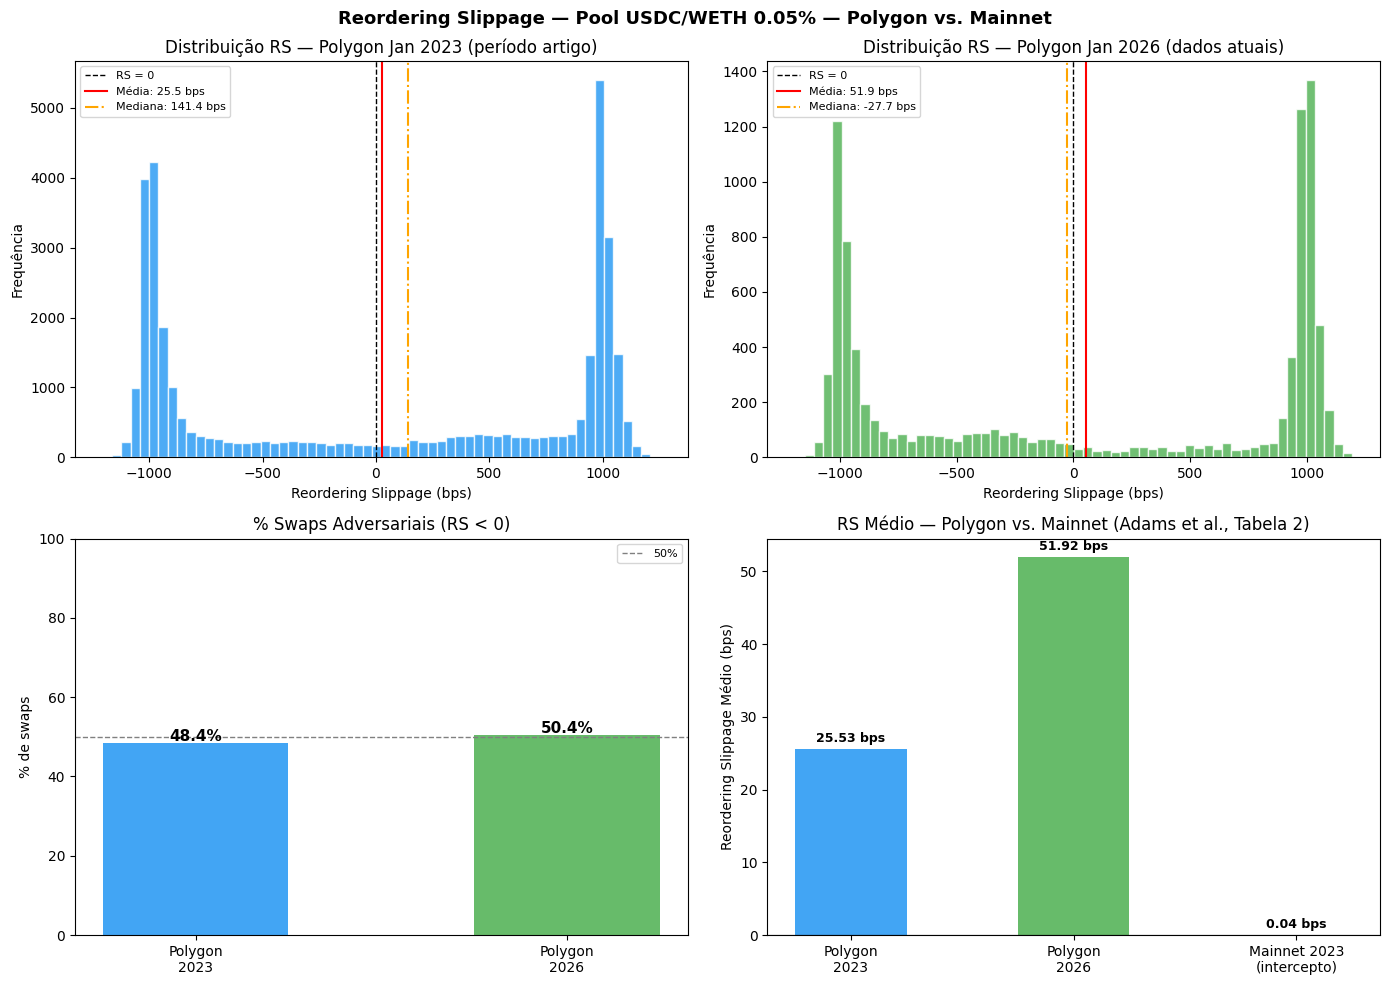

 Figura salva: comparacao_rs.png


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Reordering Slippage — Pool USDC/WETH 0.05% — Polygon vs. Mainnet",
             fontsize=13, fontweight="bold")

# ── 1. Distribuição RS — 2023 ─────────────────────────────────────────────────
ax1 = axes[0, 0]
rs_2023_clip = df_rs_2023["reordering_slippage_bps"].clip(-2000, 2000)
ax1.hist(rs_2023_clip, bins=60, color="#2196F3", alpha=0.8, edgecolor="white")
ax1.axvline(0, color="black", linestyle="--", linewidth=1, label="RS = 0")
ax1.axvline(df_rs_2023["reordering_slippage_bps"].mean(), color="red",
            linestyle="-", linewidth=1.5, label=f"Média: {df_rs_2023['reordering_slippage_bps'].mean():.1f} bps")
ax1.axvline(df_rs_2023["reordering_slippage_bps"].median(), color="orange",
            linestyle="-.", linewidth=1.5, label=f"Mediana: {df_rs_2023['reordering_slippage_bps'].median():.1f} bps")
ax1.set_title("Distribuição RS — Polygon Jan 2023 (período artigo)")
ax1.set_xlabel("Reordering Slippage (bps)")
ax1.set_ylabel("Frequência")
ax1.legend(fontsize=8)

# ── 2. Distribuição RS — 2026 ─────────────────────────────────────────────────
ax2 = axes[0, 1]
rs_2026_clip = df_rs_2026["reordering_slippage_bps"].clip(-2000, 2000)
ax2.hist(rs_2026_clip, bins=60, color="#4CAF50", alpha=0.8, edgecolor="white")
ax2.axvline(0, color="black", linestyle="--", linewidth=1, label="RS = 0")
ax2.axvline(df_rs_2026["reordering_slippage_bps"].mean(), color="red",
            linestyle="-", linewidth=1.5, label=f"Média: {df_rs_2026['reordering_slippage_bps'].mean():.1f} bps")
ax2.axvline(df_rs_2026["reordering_slippage_bps"].median(), color="orange",
            linestyle="-.", linewidth=1.5, label=f"Mediana: {df_rs_2026['reordering_slippage_bps'].median():.1f} bps")
ax2.set_title("Distribuição RS — Polygon Jan 2026 (dados atuais)")
ax2.set_xlabel("Reordering Slippage (bps)")
ax2.set_ylabel("Frequência")
ax2.legend(fontsize=8)

# ── 3. % Adversarial por período ──────────────────────────────────────────────
ax3 = axes[1, 0]
periodos_bar = ["Polygon\n2023", "Polygon\n2026", "Mainnet\n2023*"]
adv_2023 = (df_rs_2023["reordering_slippage_bps"] < 0).mean() * 100
adv_2026 = (df_rs_2026["reordering_slippage_bps"] < 0).mean() * 100
adv_mainnet = None  # não disponível diretamente
pcts = [adv_2023, adv_2026]
cores = ["#2196F3", "#4CAF50"]
bars = ax3.bar(["Polygon\n2023", "Polygon\n2026"], pcts, color=cores, alpha=0.85, width=0.5)
ax3.axhline(50, color="gray", linestyle="--", linewidth=1, label="50%")
for bar, pct in zip(bars, pcts):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{pct:.1f}%", ha="center", fontsize=11, fontweight="bold")
ax3.set_title("% Swaps Adversariais (RS < 0)")
ax3.set_ylabel("% de swaps")
ax3.set_ylim(0, 100)
ax3.legend(fontsize=8)

# ── 4. Comparação de médias (Polygon vs Mainnet baseline) ────────────────────
ax4 = axes[1, 1]
labels_comp = ["Polygon\n2023", "Polygon\n2026", "Mainnet 2023\n(intercepto)"]
medias_comp = [
    df_rs_2023["reordering_slippage_bps"].mean(),
    df_rs_2026["reordering_slippage_bps"].mean(),
    0.0412  # intercepto da Tabela 2 do artigo
]
cores_comp = ["#2196F3", "#4CAF50", "#FF5722"]
bars2 = ax4.bar(labels_comp, medias_comp, color=cores_comp, alpha=0.85, width=0.5)
ax4.axhline(0, color="black", linestyle="-", linewidth=0.8)
for bar, val in zip(bars2, medias_comp):
    offset = 1 if val >= 0 else -3
    ax4.text(bar.get_x() + bar.get_width()/2, val + offset,
             f"{val:.2f} bps", ha="center", fontsize=9, fontweight="bold")
ax4.set_title("RS Médio — Polygon vs. Mainnet (Adams et al., Tabela 2)")
ax4.set_ylabel("Reordering Slippage Médio (bps)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "comparacao_rs.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Figura salva: comparacao_rs.png")

# 7.3 Interpretação e Conclusões

Este trabalho mediu o **Reordering Slippage (RS)** — o impacto que a ordem de execução das transações dentro de um bloco tem sobre o preço que o usuário recebe — no pool USDC/WETH 0,05% da Uniswap V3 na rede Polygon, comparando com a Ethereum Mainnet (Adams et al., 2024).

Foram coletados **74.952 swaps em janeiro de 2023** (alinhados ao período do artigo de referência) e **26.979 swaps em janeiro de 2026** (dados atuais), usando a API Alchemy com busca binária de blocos para garantir precisão temporal.

---

## Resultados obtidos

A tabela abaixo resume os principais números. A coluna "amostra completa" inclui todos os swaps; a "amostra filtrada" inclui apenas blocos com 2 ou mais swaps — únicos onde o RS pode ser diferente de zero.

| Fonte | N swaps | RS Médio | RS Mediana | σ | % Adversarial |
|---|---|---|---|---|---|
| Ethereum Mainnet (Adams et al. 2024) | 258.925 | +0,04 bps* | — | — | — |
| Polygon Jan 2023 — amostra completa | 74.952 | +12,31 bps | 0,00 bps | 616 bps | 23,35% |
| Polygon Jan 2026 — amostra completa | 26.979 | +17,87 bps | 0,00 bps | 526 bps | 17,35% |
| Polygon Jan 2023 — filtrada (2+ swaps/bloco) | 36.144 | +25,53 bps | +141,43 bps | 887 bps | 48,41% |
| Polygon Jan 2026 — filtrada (2+ swaps/bloco) | 9.288 | +51,92 bps | −27,74 bps | 896 bps | 50,40% |

*\* Intercepto de regressão multivariada; estatisticamente não-significativo (p > 0,10).*

---

## O que os números significam na prática

**1. A ordem das transações importa — e muito.**
Na amostra filtrada, o desvio padrão do RS é de ~890 bps nos dois períodos. Isso significa que a posição de um swap dentro do bloco pode facilmente custar ou render centenas de pontos-base ao usuário — um efeito muito maior do que a própria taxa do pool (50 bps). Isso é evidência de que MEV existe e é relevante na Polygon.

**2. Média e mediana contam histórias diferentes — e a mediana é mais honesta.**
Em 2023, a mediana filtrada foi +141 bps: a maioria dos usuários *ganhou* em relação à ordem aleatória. Em 2026, a mediana virou −28 bps: a maioria *perdeu*. As médias ficaram positivas nos dois períodos porque poucos swaps com RS muito alto puxam a média para cima. Para entender a experiência do usuário típico, **a mediana é o número certo a olhar**.

**3. O pool ficou menos ativo entre 2023 e 2026.**
O número de blocos com 2+ swaps caiu de 12.675 (2023) para 3.915 (2026) — uma redução de ~69% na mesma janela de ~300 mil blocos. Com menos swaps simultâneos por bloco, há menos oportunidade de reordenação — o que explica por que o efeito quase desaparece na amostra completa (+12 vs. +18 bps, diferença estatisticamente não-significativa).

---

## Polygon vs. Ethereum Mainnet — a hipótese central

A hipótese H do projeto afirma que *"redes L2 apresentam Reordering Slippage significativamente menor que a Mainnet"*.

**Os dados não sustentam essa hipótese.** Em todas as métricas brutas, o RS medido na Polygon — mesmo na amostra completa (+12 a +18 bps) — é maior que o intercepto da Mainnet (+0,04 bps). Além disso, ~48–50% dos swaps em blocos com múltiplas transações foram adversariais na Polygon.

Porém, **não podemos afirmar com certeza que H é falsa**, por três razões:

1. O +0,04 bps da Mainnet vem de uma regressão com controles que não replicamos completamente na Polygon (faltam gas price, latência e tolerância a slippage). Sem esses controles, a comparação não é direta.
2. Nossa simulação de preço hipotético usa uma aproximação simplificada da pool (xy=k), enquanto o artigo usa a liquidez real por tick. Isso provavelmente inflaciona a magnitude do RS — a direção pode estar certa, mas os números absolutos devem ser interpretados com cautela.
3. Cobrimos ~7 dias de dados; o artigo cobre 7 meses. Nossa janela pode estar capturando um período atípico.

> **Conclusão mais honesta:** não encontramos evidência de que a Polygon tenha RS menor que a Mainnet — os números brutos apontam na direção oposta. Mas as limitações metodológicas são relevantes o suficiente para tratar este resultado como **preliminar**, não como uma refutação definitiva de H.

---

## Limitações e próximos passos

| Limitação | Impacto |
|---|---|
| Simulação xy=k com liquidez sintética | Inflaciona a magnitude do RS e distorce o coeficiente de tamanho de ordem na regressão |
| Janela de ~7 dias por período | Não captura sazonalidade nem eventos de mercado relevantes |
| Regressão sem gas price e latência | Erros-padrão grandes; interceptos não comparáveis diretamente com o artigo |
| % adversarial = RS < 0, não ataques confirmados | Inclui colisão benigna; sem detecção de sandwich |

**Próximos passos sugeridos:**
- Substituir a simulação xy=k pela liquidez real da pool (via eventos Mint/Burn/Swap)
- Ampliar a janela de coleta para pelo menos 1 mês contínuo
- Coletar gas price via `get_transaction_receipt` para completar a regressão
- Implementar heurística de detecção de sandwich para decompor RS em adversarial vs. colisão
- Replicar para outras redes L2 (Arbitrum, Base, Optimism) para generalizar a comparação